# 00 — SPX data, cleaned surface, and the recovered marginals

**Phase 1, deliverable 1** (`PROJECT_PLAN.md` §4).

The pipeline this notebook walks: *raw option chain → liquidity + no-arbitrage filters → SVI
smile per maturity → Breeden–Litzenberger risk-neutral marginals.*

The three things to look at:
1. the **SPX implied volatility surface**,
2. the **recovered marginals** $\mu_T(K)$ at five maturities,
3. the **forward-recovery check** — a martingale's marginal must have mean $E[S_T] = F$, so
   the residual is a direct measure of how good the extracted densities are.


In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.algorithms.preprocessing import (
    LiquidityConfig,
    PreprocessConfig,
    SurfacePreprocessor,
    implied_rate,
    implied_rate_curve,
)
from src.data.data_loader import DataLoader
from src.eval.metrics import bl_martingale_residual
from src.eval.plots import plot_iv_surface, plot_marginals, plot_smiles

pd.set_option("display.precision", 4)

## 1. Data

The SPX price series and an option-chain snapshot, both cached as parquet.

In [2]:
loader = DataLoader()

spx = loader.load_spx("2016-01-01", "2026-12-31", "1d", path=str(ROOT / "data/spx_price.parquet"))
chain = loader.load_parquet(str(ROOT / "data/spx_option_chain.parquet"))
chain = chain[chain.ttm > 0].copy()

spot = float(chain.spot.iloc[0])
snapshot = pd.to_datetime(chain.snapshot_time.iloc[0]).date()
print(f"price history : {len(spx)} days, {spx.index.min().date()} -> {spx.index.max().date()}")
print(f"option chain  : {len(chain)} quotes, {chain.expiry.nunique()} expiries, snapshot {snapshot}")
print(f"spot          : {spot:.1f}")

price history : 2628 days, 2016-01-04 -> 2026-06-16
option chain  : 2671 quotes, 8 expiries, snapshot 2026-06-16
spot          : 7511.6


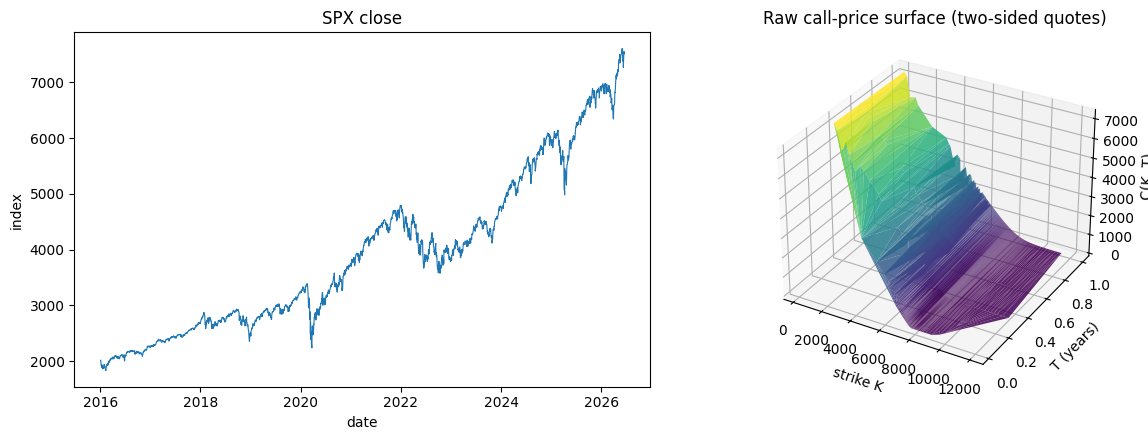

In [3]:
fig, (ax_px, ax_srf) = plt.subplots(1, 2, figsize=(13, 4.5),
                                    gridspec_kw={"width_ratios": [1, 1.2]})
ax_px.plot(spx.index, spx["Close"], lw=0.8)
ax_px.set_title("SPX close"); ax_px.set_xlabel("date"); ax_px.set_ylabel("index")

calls = chain[(chain.type == "call") & (chain.bid > 0) & (chain.ask > 0)].copy()
calls["mid"] = (calls.bid + calls.ask) / 2
ax_srf.remove()
ax_srf = fig.add_subplot(122, projection="3d")
ax_srf.plot_trisurf(calls.strike, calls.ttm, calls["mid"], cmap="viridis", alpha=0.85)
ax_srf.set_xlabel("strike K"); ax_srf.set_ylabel("T (years)"); ax_srf.set_zlabel("C(K, T)")
ax_srf.set_title("Raw call-price surface (two-sided quotes)")
fig.tight_layout(); plt.show()

## 2. The risk-free rate from the chain

Put-call parity gives $C - P = e^{-rT}(F - K)$, so regressing the call–put mid spread on strike
recovers the discount factor per expiry — with dividends already folded into $F$. 

The spread of the per-expiry rates around their median is worth a look: it is a direct
measure of how much a single flat $r$ will misprice the forward, and it is a prime suspect for
any forward-recovery error downstream.

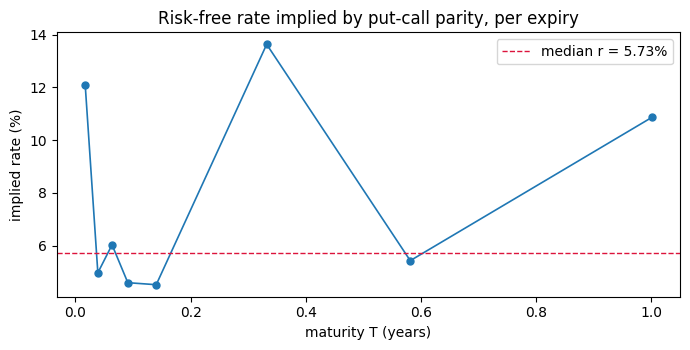

flat rate used downstream: r = 0.0573
spread across expiries   : 3.77 pp


In [4]:
r = implied_rate(chain)
curve = implied_rate_curve(chain)

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(curve.ttm, 100 * curve.rate, "o-", lw=1.2, ms=5)
ax.axhline(100 * r, color="crimson", ls="--", lw=1,
           label=f"median r = {100 * r:.2f}%")
ax.set_xlabel("maturity T (years)"); ax.set_ylabel("implied rate (%)")
ax.set_title("Risk-free rate implied by put-call parity, per expiry")
ax.legend(); fig.tight_layout(); plt.show()

print(f"flat rate used downstream: r = {r:.4f}")
print(f"spread across expiries   : {100 * curve.rate.std():.2f} pp")

## 3. Clean → SVI → marginals

`SurfacePreprocessor.prepare` runs the whole chain: liquidity filters, Carr–Madan butterfly and
calendar no-arbitrage filters, put→call conversion by parity, Black–Scholes IV inversion, a raw-SVI
fit per maturity, and finally Breeden–Litzenberger extraction $\mu_T(K) = e^{rT}\,\partial^2_K C$.

### The BL grid width is the consequential choice

BL reads the density off the smile's curvature, so wherever the grid runs past the last traded
strike, the density is being read off SVI's extrapolation rather than off data. SVI's wings grow
linearly in total variance, and on this chain the fitted right wing is steep enough that extending
the grid manufactures tail mass out of nothing. Because $E[S_T] = \int K\,\mu_T(K)\,dK$ weights by
$K$, that fake mass dominates the mean.

Measured on this chain, forward-recovery error against grid width:

| $T$ | traded $K/F$ up to | grid $\to 1.2F$ | $\to 1.5F$ | $\to 3F$ | grid = traded range |
|---|---|---|---|---|---|
| 0.14 | 1.08 | +0.03% | +7.3% | **+35.7%** | **+0.15%** |
| 0.33 | 1.15 | +0.17% | +27.5% | **+27.5%** | **+0.12%** |
| 0.58 | 1.20 | +0.45% | +23.1% | **+23.0%** | **+0.73%** |

So the grid spans exactly the strikes that traded (`grid_mode="traded"`, the default). The
extracted density is then the risk-neutral density conditional on the traded range, renormalised
— and `raw_mass` reports the probability the range failed to capture, so the truncation is stated
rather than hidden. `grid_mode="fixed"` restores the old fraction-of-forward grid; it is safe on a
synthetic smile (where the smile is the true model) and misleading on market data.

In [5]:
cfg = PreprocessConfig(
    # SPX yfinance quotes are thin on volume, so lean on open interest + a tight spread.
    liquidity=LiquidityConfig(min_volume=0, min_open_interest=1, max_rel_spread=0.05),
)
surface = SurfacePreprocessor(cfg).prepare(chain, r=r)
clean, svi, margs = surface.clean, surface.svi, surface.marginals

# five maturities spread across the whole term structure, not just the clustered short end
pick = sorted({int(round(x)) for x in np.linspace(0, len(svi) - 1, 5)})
picked_ttms = [svi[i].t for i in pick]

print(f"clean quotes : {len(clean)}  ({clean.ttm.nunique()} maturities)")
print(f"maturities   : {', '.join(f'{t:.2f}y' for t in sorted(clean.ttm.unique()))}")
print(f"BL grid mode : {cfg.marginal.grid_mode!r}  ({cfg.marginal.n_grid} points per maturity)")

clean quotes : 860  (8 maturities)
maturities   : 0.02y, 0.04y, 0.06y, 0.09y, 0.14y, 0.33y, 0.58y, 1.00y
BL grid mode : 'traded'  (400 points per maturity)


### 3a. The implied volatility surface

**Exit-criterion figure #1.** The mesh is built from the fitted SVI slices by interpolating
**total variance** $w = \sigma^2 T$ linearly in $T$ and recovering $\sigma = \sqrt{w/T}$ —
interpolating the vol directly would let $w$ *decrease* with maturity, which is exactly calendar
arbitrage.

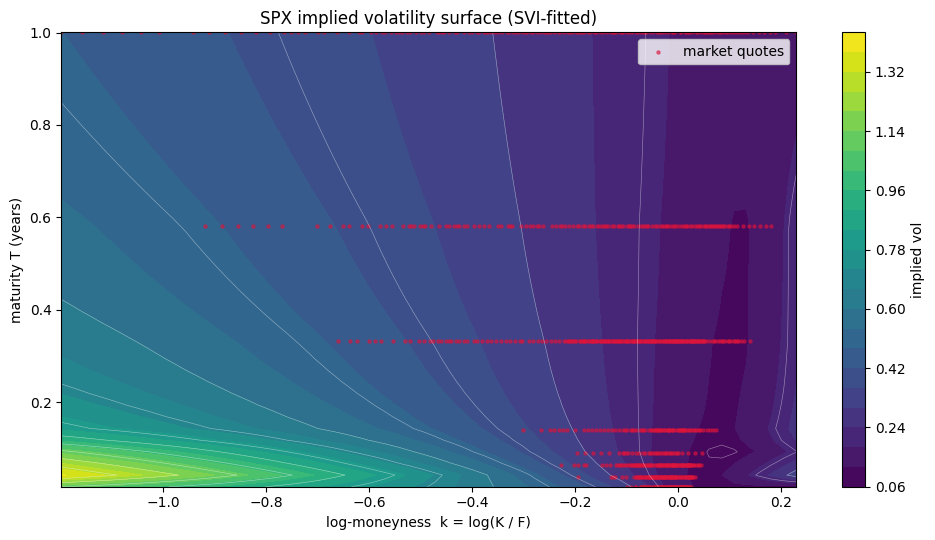

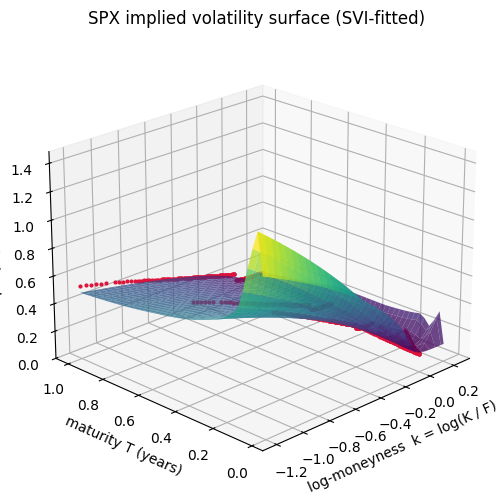

In [6]:
fig, ax = plt.subplots(figsize=(10, 5.5))
plot_iv_surface(clean, svi, kind="contour", ax=ax)
fig.tight_layout(); plt.show()

plot_iv_surface(clean, svi, kind="surface")
plt.show()

### 3b. SVI smiles against the market

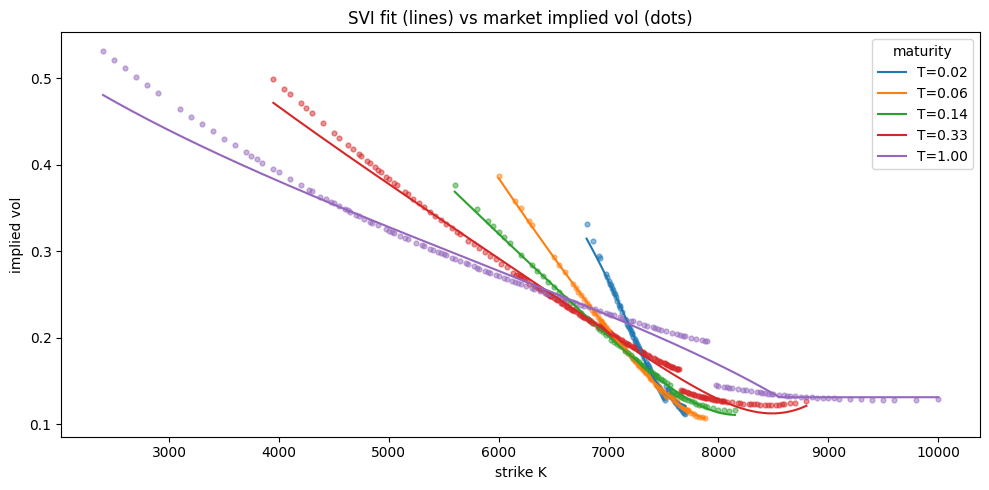

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_smiles(clean, svi, ttms=picked_ttms, ax=ax)
fig.tight_layout(); plt.show()

### 3c. The recovered marginals

**Exit-criterion figure #2.** Each curve is a risk-neutral terminal density $\mu_T(K)$ extracted
from the surface. These are the calibration *targets* for Phase 2 — the neural SDE's simulated
marginals get matched against exactly these.

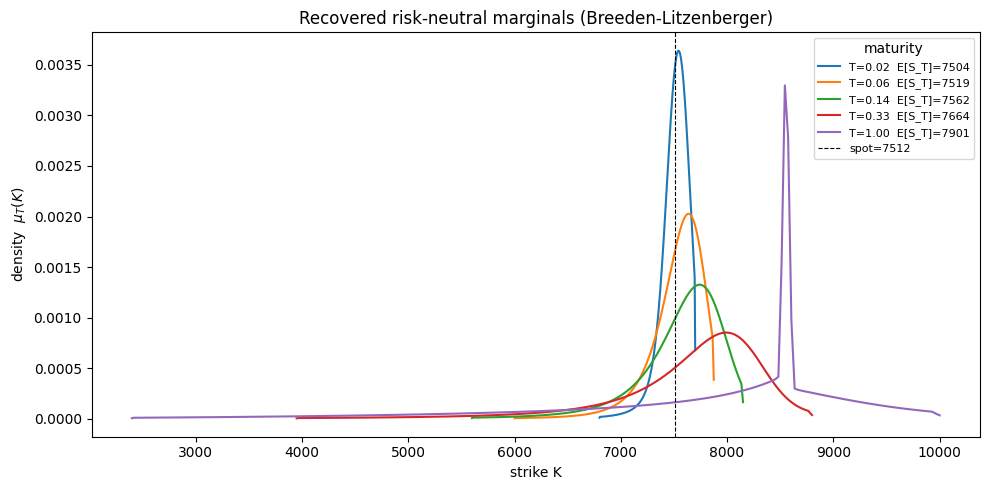

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_marginals([margs[i] for i in pick], s_0=spot, ax=ax)
fig.tight_layout(); plt.show()

## 4. Forward recovery — does the data behave like a martingale?

Under $\mathbb{Q}$, $E[S_T] = F = S_0 e^{rT}$. The mean of each extracted density should therefore
be the forward, and the residual is a scorecard for the **data**, before any model is fitted.

Read it alongside `raw_mass` — the probability the traded strike range actually captured. The two
columns separate the failure modes: `raw_mass` well below 1 means the quotes simply do not span the
tails (so the mean is a *conditional* mean and is biased low), whereas a large residual at
`raw_mass ≈ 1` would mean the density itself is wrong. `k_lo`/`k_hi` are the grid bounds in
log-moneyness, i.e. how far the market actually quotes.

In [9]:
resid = bl_martingale_residual(margs, s_0=spot, r=r)
display(resid.assign(**{"rel_resid_%": 100 * resid.rel_residual})
        .drop(columns=["rel_residual", "residual"])
        .style.format({"ttm": "{:.3f}", "e_s_t": "{:.0f}", "forward": "{:.0f}",
                       "rel_resid_%": "{:+.2f}", "raw_mass": "{:.3f}",
                       "k_lo": "{:+.2f}", "k_hi": "{:+.2f}"}))

print(f"worst |relative residual| : {100 * resid.rel_residual.abs().max():.2f}%")
print(f"raw_mass, min..max        : {resid.raw_mass.min():.3f} .. {resid.raw_mass.max():.3f}")

,ttm,e_s_t,forward,raw_mass,k_lo,k_hi,rel_resid_%
0,0.017,7504,7519,0.925,-0.10,+0.02,-0.19
1,0.039,7505,7528,0.920,-0.19,+0.03,-0.30
2,0.063,7519,7539,0.937,-0.23,+0.04,-0.27
3,0.091,7521,7551,0.900,-0.20,+0.05,-0.39
4,0.140,7562,7572,0.956,-0.30,+0.07,-0.14
5,0.332,7664,7656,0.988,-0.66,+0.14,+0.11
6,0.581,7820,7766,1.025,-0.92,+0.18,+0.70
7,1.000,7901,7955,0.957,-1.20,+0.23,-0.68


worst |relative residual| : 0.70%
raw_mass, min..max        : 0.900 .. 1.025
